# Concept swaps in J-lens coordinates — GPT-2 XL

Replace the model's representation of one concept with another's in J-lens coordinates and
check that the answer changes accordingly, as in the paper's two-hop and flexible-generalization
swaps (`data/experiments/probe-swap.json`, `flexible-generalization.json`). Example:
*"The capital of France is the city of"* with France → China should answer *Beijing*.
The paper's two-hop prompts are too hard for GPT-2 XL (16% answered), so we add
`latent-bridge.json`: *"The Eiffel Tower is in a country where the main language is"* — the
country is never named, and swapping France → Japan should answer *Japanese*.

**Answer (this run, §4).** J-lens swaps work on GPT-2 XL and are specific. On the latent-bridge
set (284 of 400 trials answered correctly) the best setting flips 88% of answers to the swapped
country's language (α = 2, band 16–40; 95% CI 84–92%), with random directions of the same size at
≤ 4%. On the paper's sets up to 75% of flexible-generalization and 54% of two-hop swaps flip
(random ≤ 10%). Without J (logit-lens directions) swaps fail in early and middle layers; there the
J-lens directions are what carries the concept.

**Concept probes (§2).** Following the `probe-swap` protocol, we also swap difference-of-means
probe directions learned from prompts that name the concept explicitly. They match J-lens swaps
when the concept is named in the prompt (flexible: 76% vs 75%), but transfer worse to the latent
country (latent-bridge: 64% vs 88%). The probe direction is closer to the concept's J-lens direction
(mean cosine 0.45 → 0.15 from layer 0 to 46) than to its logit-lens direction (0.07–0.17).

## Method

**Lens vectors.** The J-lens logit of token t at layer l is `u_tᵀ C(γ ⊙ J_l h)/σ` (`u_t`: the
unembedding row; `γ`, `C`: the `ln_f` gain and centering; `σ` is shared by all tokens). Its
direction in the residual stream is `v_t = J_lᵀ C(γ ⊙ u_t)` — a row of `W_U J_l` with the final
norm folded in. The logit-lens control uses `J_l = I`.

**Swap (clamping).** For source s and target t, `V = [v_s v_t]` and coordinates `c = V⁺h`. A
clean pass records `c_clean` at every band layer and position; the patched pass sets, after
each band block, `h ← h + V(c* − V⁺h)` with `c* = c_clean + α(swap(c_clean) − c_clean)`. At
α = 1 the two coordinates are exchanged; the component of h orthogonal to `span(V)` is kept.
All prompt positions except BOS are patched, as in the paper (*"at every token position across
a band of intermediate layers"*).

Clamping matters with a band: applying the swap `h + αV(swap(c) − c)` to the already patched
stream at each layer undoes it at every second layer (the coordinates carried over are
swapped back), and with α > 1 the overshoot compounds.

**Single tokens.** Trials are kept only if the source and target concepts are single tokens
(with a leading space) and both answers have a single-token spelling: a multi-token concept would
be swapped through its first fragment's direction, and a multi-token answer scored by its first
fragment (`" sh"` for *shiver*). This drops 22 flexible and 11 two-hop trials; latent-bridge is
unaffected.

**Grid.** Bands of block outputs 8–16, 16–24, 24–32, 32–40, 40–47, 12–36, 16–40 (GPT-2 XL has
no published workspace band); α ∈ {1, 2, 4}; directions `J`, `logit`, `probe` (difference of means, §2), and `random` (each
position's J-swap update norm in a random direction).

**Batching.** Trials are grouped by length, right-padded, and run 64 at a time; GPT-2 is
causal, so no attention mask is needed and each row is read at its last real token. Each row
carries its own basis `V` and clean activations.

**Success.** The next-token top-1 is a spelling of the swap answer. Reported over all trials
and over trials the model answers correctly without intervention, with Wilson 95% intervals.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoTokenizer

import jlens
from gpt2 import GPT2LensModel
from jlens.evaluation import single_token_ids, spelling_ids
from jlens.hooks import ActivationRecorder

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl-convergence"))
LENS_PATH = RUN_DIR / "snapshot_lens_134.pt"
OUT_DIR = RUN_DIR / "swap"
CACHES = {"swap_trials.csv": ["probe-swap", "flexible"], "swap_trials_latent-bridge.csv": ["latent-bridge"]}
SETS = ["flexible", "probe-swap", "latent-bridge"]
PROBE_PATH = OUT_DIR / "probe_vectors.pt"
BANDS = ["8-16", "16-24", "24-32", "32-40", "40-47", "12-36", "16-40"]  # half-open block-output ranges
ALPHAS = [1.0, 2.0, 4.0]
MODES = ["J", "logit", "probe", "random"]
BATCH_SIZE = 64  # trials per forward pass
OUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

## 1. Trials

In [4]:
def load_trials() -> pd.DataFrame:
    trials = []
    for name in ("probe-swap", "latent-bridge"):
        for item in json.load(open(Path(REPO_DIR) / f"data/experiments/{name}.json"))["items"]:
            trials.append({"set": name, "group": item["category"], "name": item["name"],
                           "prompt": item["prompt"].rstrip(), "source": item["intermediate"],
                           "target": item["swap_to"], "answer": item["answer"], "swap_answer": item["swap_answer"]})
    for category in json.load(open(Path(REPO_DIR) / "data/experiments/flexible-generalization.json"))["categories"]:
        for func in category["funcs"]:
            for source in category["args"]:
                for target in category["args"]:
                    if target != source:
                        trials.append({
                            "set": "flexible", "group": f"{category['name']}/{func['name']}",
                            "name": f"{func['name']}:{source}->{target}",
                            "prompt": func["template"].format(arg=source).rstrip(), "source": source,
                            "target": target, "answer": func["answers"][source],
                            "swap_answer": func["answers"][target]})
    return pd.DataFrame(trials)


def single_token_mask(trials: pd.DataFrame) -> pd.Series:
    """Concepts are single tokens with a leading space; answers have a single-token spelling."""
    tok = AutoTokenizer.from_pretrained(MODEL_ID)

    def concept(word):
        return len(tok.encode(" " + word, add_special_tokens=False)) == 1

    def answer(word):
        return bool(single_token_ids(tok, word))

    return (trials.source.map(concept) & trials.target.map(concept)
            & trials.answer.map(answer) & trials.swap_answer.map(answer))


trials = load_trials()
single = single_token_mask(trials)
display(trials.assign(kept=single).groupby("set").kept.agg(trials="size", kept="sum"))
display(trials[~single][["set", "source", "target", "answer", "swap_answer"]].drop_duplicates())
trials = trials[single].reset_index(drop=True)
trials.groupby("set").head(2)[["set", "prompt", "source", "target", "answer", "swap_answer"]]

,trials,kept
set,,
flexible,192,170
latent-bridge,400,400
probe-swap,90,79


,set,source,target,answer,swap_answer
7,probe-swap,swan,eagle,white,brown
8,probe-swap,eagle,swan,America,England
17,probe-swap,Italy,Mexico,Euro,peso
28,probe-swap,Canada,India,Canadian,rupee
55,probe-swap,pearl,diamond,oyster,earth
64,probe-swap,brain,heart,skull,ribcage
66,probe-swap,Michigan,Wisconsin,wolverine,badger
68,probe-swap,Lincoln,Napoleon,Civil,Napoleonic
73,probe-swap,Mozart,Darwin,Wolfgang,Charles
75,probe-swap,Shakespeare,Mozart,William,Wolfgang


,set,prompt,source,target,answer,swap_answer
0,probe-swap,Fact: The language spoken in the country where...,Brazil,Mexico,Portuguese,Spanish
1,probe-swap,Fact: The hard covering on the back of the slo...,turtle,snake,shell,scale
79,latent-bridge,The Eiffel Tower is in a country where the mai...,France,Peru,French,Spanish
80,latent-bridge,The Eiffel Tower is in a country where the mai...,France,Poland,French,Polish
479,flexible,The capital of France is the city of,France,Canada,Paris,Ottawa
480,flexible,The capital of France is the city of,France,China,Paris,Beijing


## 2. Concept probes (difference of means)

`probe-swap` swaps a *linear-probe direction* for the bridge entity, not a lens direction. We
build one per concept and layer by difference of means on prompts that name the concept
explicitly and share nothing with the test prompts: each template in
`data/experiments/concept-probe-templates.json` is filled with every concept, and the block output
is read at the concept token. `w_c = mean_templates h(c) − mean_concepts mean_templates h(c')`, so
template-specific activity cancels. The swap uses the same clamp with `V = [w_s w_t]`; clamping
swaps coordinates, so the scale of `w` does not matter.

Below: mean cosine between `w_c` and the J-lens / logit-lens direction of the same concept token,
and with the J-lens direction of a different concept as a control.

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

probe prompts:   0%|          | 0/33 [00:00<?, ?it/s]

104 concepts x 20 templates, vectors (47, 104, 1600)


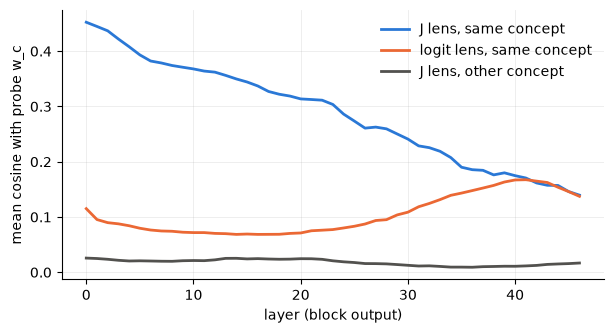

In [5]:
CONCEPTS = sorted(set(trials.source) | set(trials.target))
PROBE_TEMPLATES = json.load(open(Path(REPO_DIR) / "data/experiments/concept-probe-templates.json"))["templates"]


def cache_complete(name):
    path = OUT_DIR / name
    return path.exists() and set(pd.read_csv(path, usecols=["mode"])["mode"]) == set(MODES)


missing = {name: sets for name, sets in CACHES.items() if not cache_complete(name)}
probe_cache = torch.load(PROBE_PATH) if PROBE_PATH.exists() else None
if probe_cache is not None and (probe_cache["concepts"], probe_cache["templates"]) != (CONCEPTS, PROBE_TEMPLATES):
    probe_cache = None
model = None
if missing or probe_cache is None:
    model = GPT2LensModel.from_pretrained(MODEL_ID, device=DEVICE)
    tok = model.tokenizer
    lens = jlens.JacobianLens.load(str(LENS_PATH))
    jacobians = {layer: J.to(DEVICE) for layer, J in lens.jacobians.items()}
    W_U = model._lm_head.weight.float()
    gamma = model._final_norm.weight.float()
    LAYERS = range(model.n_layers - 1)

if probe_cache is None:
    @torch.no_grad()
    def concept_means():
        """[layer, concept, d] block output at the concept token, averaged over templates."""
        sums = torch.zeros(len(LAYERS), len(CONCEPTS), model.d_model, device=DEVICE)
        pairs = [(c, template) for c in range(len(CONCEPTS)) for template in PROBE_TEMPLATES]
        for start in tqdm(range(0, len(pairs), BATCH_SIZE), desc="probe prompts"):
            chunk = pairs[start:start + BATCH_SIZE]
            encoded, positions = [], []
            for c, template in chunk:
                ids = model.encode(template.format(x=CONCEPTS[c]))[0]
                position = model.encode(template.split("{x}")[0].rstrip()).shape[1]
                assert int(ids[position]) == tok.encode(" " + CONCEPTS[c])[0], (template, CONCEPTS[c])
                encoded.append(ids)
                positions.append(position)
            ids = torch.nn.utils.rnn.pad_sequence(encoded, batch_first=True, padding_value=tok.eos_token_id)
            rows = torch.arange(len(chunk), device=DEVICE)
            index = torch.tensor([c for c, _ in chunk], device=DEVICE)
            with ActivationRecorder(model.layers, at=LAYERS) as recorder:
                model.forward(ids)
            for layer in LAYERS:
                sums[layer].index_add_(0, index, recorder.activations[layer][rows, positions].float())
        return sums / len(PROBE_TEMPLATES)

    means = concept_means()
    vectors = means - means.mean(1, keepdim=True)
    token_ids = torch.tensor([tok.encode(" " + concept)[0] for concept in CONCEPTS], device=DEVICE)
    g = gamma * W_U[token_ids]
    g = g - g.mean(-1, keepdim=True)
    cos = {"J lens, same concept": [], "logit lens, same concept": [], "J lens, other concept": []}
    for layer in LAYERS:
        v = g @ jacobians[layer]
        cos["J lens, same concept"].append(F.cosine_similarity(vectors[layer], v, dim=-1).mean().item())
        cos["logit lens, same concept"].append(F.cosine_similarity(vectors[layer], g, dim=-1).mean().item())
        cos["J lens, other concept"].append(
            F.cosine_similarity(vectors[layer], v.roll(1, 0), dim=-1).mean().item())
    torch.save({"concepts": CONCEPTS, "templates": PROBE_TEMPLATES, "vectors": vectors.cpu(), "cos": cos}, PROBE_PATH)
    probe_cache = torch.load(PROBE_PATH)
probe_vectors = probe_cache["vectors"]
print(f"{len(CONCEPTS)} concepts x {len(PROBE_TEMPLATES)} templates, vectors {tuple(probe_vectors.shape)}")

fig, ax = plt.subplots(figsize=(7, 3.5))
for (label, values), color in zip(probe_cache["cos"].items(), ("#2a78d6", "#eb6834", "#52514e"), strict=True):
    ax.plot(values, color=color, lw=2, label=label)
ax.set_xlabel("layer (block output)")
ax.set_ylabel("mean cosine with probe w_c")
ax.grid(alpha=0.25, lw=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()

## 3. Run

Each file in `CACHES` is skipped when it exists and holds every mode in `MODES` (~1.5 min on a
V100 for the 249 paper trials and ~2.5 min for the 400 latent-bridge trials, × 84 settings each;
the probe vectors take ~10 s).

In [6]:
if missing:
    concept_index = {concept: i for i, concept in enumerate(CONCEPTS)}
    probe_on_device = probe_vectors.to(DEVICE)

    def concept_token(word):
        ids = tok.encode(" " + word, add_special_tokens=False)
        return ids[0], len(ids) == 1

    trials["source_id"], trials["source_single"] = zip(*trials.source.map(concept_token), strict=True)
    trials["target_id"], trials["target_single"] = zip(*trials.target.map(concept_token), strict=True)

    trials["source_idx"], trials["target_idx"] = trials.source.map(concept_index), trials.target.map(concept_index)

    class Bases:
        """Per-row V = [v_s v_t] (stored transposed, [batch, 2, d]) and pseudoinverses, cached by (layer, kind)."""

        def __init__(self, chunk):
            g = gamma * W_U[torch.tensor(chunk[["source_id", "target_id"]].values, device=DEVICE)]  # [batch, 2, d]
            self.unembed = g - g.mean(-1, keepdim=True)
            self.concepts = torch.tensor(chunk[["source_idx", "target_idx"]].values, device=DEVICE)
            self.cache = {}

        def __call__(self, layer, mode):
            kind = "J" if mode == "random" else mode  # random mode uses the J basis for the update norm
            if (layer, kind) not in self.cache:
                if kind == "probe":
                    Vt = probe_on_device[layer][self.concepts]
                elif kind == "logit":
                    Vt = self.unembed
                else:
                    Vt = self.unembed @ jacobians[layer]
                self.cache[layer, kind] = (Vt, torch.linalg.pinv(Vt.transpose(1, 2)))
            return self.cache[layer, kind]

    class Swap:
        """Clamp each row's (source, target) lens coordinates at every hooked layer to swapped clean values."""

        def __init__(self, layers, bases, alpha, mode, clean):
            self.bases, self.alpha, self.mode, self.clean = bases, alpha, mode, clean
            self.handles = [model.layers[layer].register_forward_hook(self.hook(layer)) for layer in layers]

        def hook(self, layer):
            def fn(module, inputs, output):
                h = output if torch.is_tensor(output) else output[0]
                Vt, V_pinv = self.bases(layer, self.mode)
                c = torch.einsum("btd,bkd->btk", h[:, 1:].float(), V_pinv)  # BOS skipped
                c_clean = torch.einsum("btd,bkd->btk", self.clean[layer][:, 1:].float(), V_pinv)
                target = c_clean + self.alpha * (c_clean[..., [1, 0]] - c_clean)
                update = torch.einsum("btk,bkd->btd", target - c, Vt)
                if self.mode == "random":
                    direction = torch.randn_like(update)
                    update = direction / direction.norm(dim=-1, keepdim=True) * update.norm(dim=-1, keepdim=True)
                h = h.clone()
                h[:, 1:] += update.to(h.dtype)
                return h if torch.is_tensor(output) else (h, *output[1:])
            return fn

        def __enter__(self):
            return self

        def __exit__(self, *exc):
            for handle in self.handles:
                handle.remove()

    answer_ids = {}

    def answer_mask(words):
        """[batch, vocab] mask of each row's answer spellings."""
        mask = torch.zeros(len(words), W_U.shape[0], dtype=torch.bool, device=DEVICE)
        for row, word in enumerate(words):
            if word not in answer_ids:
                answer_ids[word] = sorted(spelling_ids(tok, word))
            mask[row, answer_ids[word]] = True
        return mask

    @torch.no_grad()
    def next_token_logits(ids, last):
        # Right padding needs no attention mask: GPT-2 is causal and each row is read at its last real token.
        hidden = model.forward(ids).last_hidden_state  # ln_f already applied
        return model._lm_head(hidden[torch.arange(len(ids), device=DEVICE), last]).float()

    def ranks(logits, mask):
        best = logits.masked_fill(~mask, -torch.inf).max(-1, keepdim=True).values
        return (logits > best).sum(-1) + 1

    for name, sets in missing.items():
        rows = []
        subset = trials[trials.set.isin(sets)]
        encoded = [model.encode(prompt)[0] for prompt in subset.prompt]
        order = np.argsort([len(ids) for ids in encoded], kind="stable")  # similar lengths share a batch
        for start in tqdm(range(0, len(order), BATCH_SIZE), desc=name):
            index = order[start:start + BATCH_SIZE]
            chunk = subset.iloc[index]
            ids = torch.nn.utils.rnn.pad_sequence([encoded[i] for i in index], batch_first=True,
                                                  padding_value=tok.eos_token_id)
            last = torch.tensor([len(encoded[i]) - 1 for i in index], device=DEVICE)
            answer, swap_answer = answer_mask(chunk.answer), answer_mask(chunk.swap_answer)
            with ActivationRecorder(model.layers, at=range(model.n_layers - 1)) as recorder:
                base = next_token_logits(ids, last)
            clean = {layer: activation.detach() for layer, activation in recorder.activations.items()}
            bases = Bases(chunk)
            base_top1 = base.argmax(-1)
            base_rows = [{**trial.drop(["prompt"]).to_dict(), "base_top1": tok.decode([top]),
                          "base_correct": correct, "base_rank_swap": rank}
                         for (_, trial), top, correct, rank in zip(
                             chunk.iterrows(), base_top1.tolist(),
                             answer[torch.arange(len(index)), base_top1].tolist(),
                             ranks(base, swap_answer).tolist(), strict=True)]
            for band in BANDS:
                layer_start, layer_stop = map(int, band.split("-"))
                for mode in MODES:
                    for alpha in ALPHAS:
                        with Swap(range(layer_start, layer_stop), bases, alpha, mode, clean):
                            patched = next_token_logits(ids, last)
                        top1 = patched.argmax(-1)
                        for row, top, success, rank_swap, rank_answer in zip(
                                base_rows, top1.tolist(), swap_answer[torch.arange(len(index)), top1].tolist(),
                                ranks(patched, swap_answer).tolist(), ranks(patched, answer).tolist(), strict=True):
                            rows.append({**row, "band": band, "mode": mode, "alpha": alpha,
                                         "top1": tok.decode([top]), "success": success,
                                         "rank_swap": rank_swap, "rank_answer": rank_answer})
        pd.DataFrame(rows).to_csv(OUT_DIR / name, index=False)
model = jacobians = None  # free GPU memory
results = pd.concat([pd.read_csv(OUT_DIR / name) for name in CACHES], ignore_index=True)
results = results.merge(trials[["set", "name"]], on=["set", "name"])  # caches may hold filtered-out trials
print(len(results), "rows")

swap_trials.csv:   0%|          | 0/4 [00:00<?, ?it/s]

swap_trials_latent-bridge.csv:   0%|          | 0/7 [00:00<?, ?it/s]

54516 rows


## 4. Results

### Baseline: does GPT-2 XL answer without intervention?

In [7]:
base = results.drop_duplicates(["set", "name"])
base.groupby("set").agg(trials=("base_correct", "size"), correct=("base_correct", "sum"),
                        accuracy=("base_correct", "mean")).round(3)

,trials,correct,accuracy
set,,,
flexible,170,51,0.300
latent-bridge,400,284,0.710
probe-swap,79,13,0.165


### Swap success over all trials

In [8]:
def success_table(frame):
    return frame.groupby(["set", "mode", "alpha", "band"]).success.mean().unstack("band")[BANDS].round(3)


success_table(results)

band                         8-16  16-24  24-32  32-40  40-47  12-36  16-40
set           mode   alpha                                                 
flexible      J      1.0    0.071  0.082  0.088  0.165  0.171  0.218  0.229
                     2.0    0.288  0.253  0.224  0.159  0.124  0.229  0.182
                     4.0    0.276  0.271  0.188  0.082  0.029  0.112  0.076
              logit  1.0    0.000  0.000  0.018  0.147  0.153  0.088  0.153
                     2.0    0.000  0.000  0.141  0.124  0.124  0.141  0.124
                     4.0    0.006  0.059  0.124  0.047  0.029  0.059  0.047
              probe  1.0    0.306  0.312  0.276  0.159  0.047  0.294  0.288
                     2.0    0.271  0.253  0.224  0.135  0.094  0.200  0.212
                     4.0    0.129  0.176  0.141  0.065  0.035  0.076  0.071
              random 1.0    0.000  0.012  0.000  0.006  0.018  0.024  0.012
                     2.0    0.035  0.024  0.029  0.006  0.012  0.012  0.047
                     4.0    0.029  0.053  0.024  0.012  0.012  0.024  0.006
latent-bridge J      1.0    0.068  0.110  0.230  0.507  0.430  0.470  0.568
                     2.0    0.280  0.440  0.660  0.720  0.655  0.715  0.755
                     4.0    0.500  0.612  0.742  0.558  0.392  0.718  0.562
              logit  1.0    0.018  0.018  0.072  0.470  0.435  0.292  0.485
                     2.0    0.022  0.040  0.472  0.680  0.625  0.648  0.690
                     4.0    0.055  0.175  0.658  0.458  0.375  0.618  0.442
              probe  1.0    0.168  0.298  0.418  0.280  0.160  0.458  0.445
                     2.0    0.352  0.502  0.562  0.342  0.298  0.482  0.355
                     4.0    0.388  0.410  0.418  0.245  0.305  0.252  0.252
              random 1.0    0.020  0.018  0.015  0.012  0.015  0.022  0.015
                     2.0    0.020  0.018  0.018  0.022  0.028  0.045  0.040
                     4.0    0.030  0.032  0.035  0.028  0.022  0.040  0.030
probe-swap    J      1.0    0.013  0.013  0.025  0.063  0.025  0.076  0.089
                     2.0    0.089  0.101  0.127  0.101  0.089  0.114  0.127
                     4.0    0.127  0.139  0.114  0.038  0.051  0.063  0.038
              logit  1.0    0.000  0.013  0.013  0.076  0.025  0.025  0.076
                     2.0    0.000  0.013  0.025  0.076  0.076  0.101  0.089
                     4.0    0.013  0.013  0.101  0.038  0.051  0.038  0.038
              probe  1.0    0.063  0.063  0.089  0.089  0.063  0.089  0.076
                     2.0    0.101  0.089  0.101  0.089  0.051  0.114  0.101
                     4.0    0.063  0.063  0.076  0.063  0.038  0.063  0.063
              random 1.0    0.013  0.000  0.000  0.025  0.013  0.000  0.013
                     2.0    0.013  0.000  0.000  0.025  0.013  0.013  0.000
                     4.0    0.000  0.000  0.000  0.013  0.013  0.000  0.000

### Swap success over baseline-correct trials

Only trials the model answers correctly can show that the swap moves the *computed* answer.
Wilson 95% intervals for the best setting of each direction:

In [9]:
correct = results[results.base_correct]
display(success_table(correct))


def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


grouped = correct.groupby(["set", "mode", "alpha", "band"]).success.agg(["sum", "size"]).reset_index()
best = grouped.loc[grouped.groupby(["set", "mode"])["sum"].idxmax()].copy()
best["rate"] = best["sum"] / best["size"]
best["CI lo"], best["CI hi"] = wilson(best["sum"], best["size"])
best.round(3)

band                         8-16  16-24  24-32  32-40  40-47  12-36  16-40
set           mode   alpha                                                 
flexible      J      1.0    0.196  0.235  0.275  0.490  0.510  0.569  0.608
                     2.0    0.745  0.647  0.608  0.431  0.314  0.569  0.471
                     4.0    0.647  0.647  0.471  0.157  0.098  0.235  0.157
              logit  1.0    0.000  0.000  0.059  0.451  0.451  0.275  0.471
                     2.0    0.000  0.000  0.412  0.373  0.294  0.431  0.373
                     4.0    0.020  0.137  0.373  0.137  0.098  0.176  0.157
              probe  1.0    0.745  0.765  0.686  0.373  0.098  0.725  0.667
                     2.0    0.706  0.627  0.588  0.333  0.235  0.471  0.510
                     4.0    0.333  0.412  0.353  0.137  0.059  0.176  0.137
              random 1.0    0.000  0.020  0.000  0.020  0.020  0.039  0.020
                     2.0    0.078  0.039  0.039  0.000  0.020  0.020  0.098
                     4.0    0.059  0.098  0.059  0.020  0.000  0.059  0.020
latent-bridge J      1.0    0.053  0.120  0.278  0.620  0.528  0.585  0.687
                     2.0    0.345  0.539  0.817  0.863  0.771  0.859  0.884
                     4.0    0.588  0.715  0.849  0.570  0.352  0.778  0.577
              logit  1.0    0.000  0.004  0.074  0.581  0.535  0.356  0.595
                     2.0    0.007  0.032  0.599  0.810  0.729  0.789  0.820
                     4.0    0.042  0.201  0.792  0.465  0.352  0.704  0.444
              probe  1.0    0.176  0.342  0.496  0.327  0.173  0.532  0.514
                     2.0    0.391  0.574  0.637  0.401  0.313  0.549  0.391
                     4.0    0.401  0.430  0.472  0.246  0.310  0.268  0.264
              random 1.0    0.000  0.000  0.000  0.000  0.000  0.004  0.007
                     2.0    0.000  0.000  0.011  0.018  0.011  0.039  0.021
                     4.0    0.025  0.018  0.025  0.021  0.014  0.032  0.014
probe-swap    J      1.0    0.000  0.000  0.077  0.231  0.077  0.308  0.385
                     2.0    0.385  0.385  0.385  0.308  0.154  0.385  0.385
                     4.0    0.385  0.538  0.385  0.077  0.077  0.231  0.077
              logit  1.0    0.000  0.000  0.000  0.231  0.077  0.077  0.231
                     2.0    0.000  0.000  0.077  0.231  0.154  0.385  0.231
                     4.0    0.000  0.000  0.231  0.077  0.077  0.077  0.077
              probe  1.0    0.308  0.308  0.308  0.231  0.154  0.308  0.231
                     2.0    0.308  0.385  0.385  0.231  0.077  0.462  0.308
                     4.0    0.077  0.154  0.077  0.154  0.000  0.077  0.077
              random 1.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000
                     2.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000
                     4.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000

,set,mode,alpha,band,sum,size,rate,CI lo,CI hi
13,flexible,J,2.0,8-16,38,51,0.745,0.611,0.845
23,flexible,logit,1.0,16-40,24,51,0.471,0.341,0.605
43,flexible,probe,1.0,16-24,39,51,0.765,0.632,0.860
72,flexible,random,2.0,16-40,5,51,0.098,0.043,0.210
93,latent-bridge,J,2.0,16-40,251,284,0.884,0.841,0.916
114,latent-bridge,logit,2.0,16-40,233,284,0.820,0.772,0.861
136,latent-bridge,probe,2.0,24-32,181,284,0.637,0.580,0.691
154,latent-bridge,random,2.0,12-36,11,284,0.039,0.022,0.068
183,probe-swap,J,4.0,16-24,7,13,0.538,0.291,0.768
196,probe-swap,logit,2.0,12-36,5,13,0.385,0.177,0.645


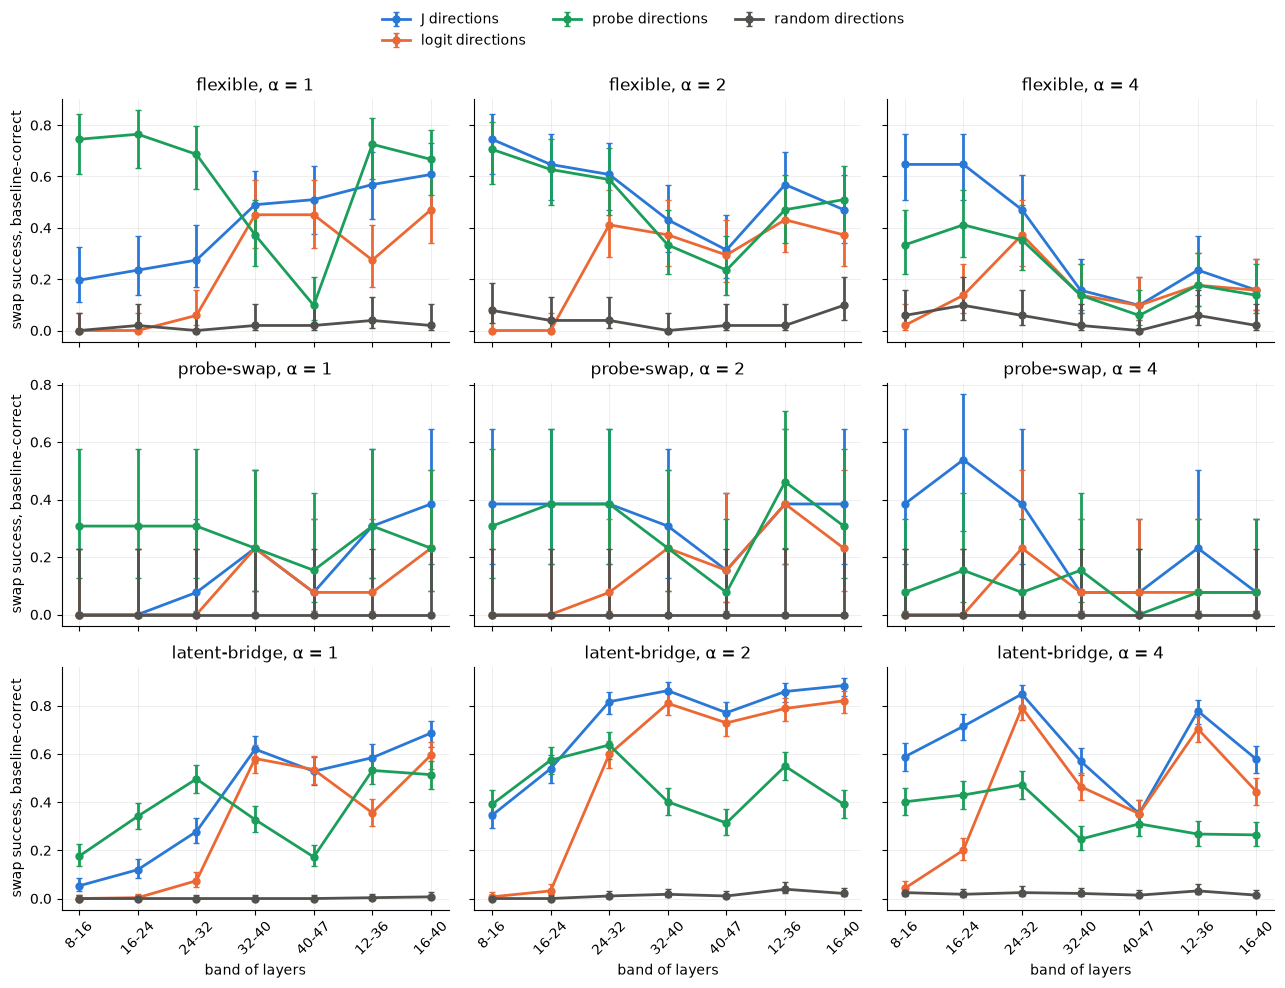

In [10]:
COLORS = {"J": "#2a78d6", "logit": "#eb6834", "probe": "#1b9e5a", "random": "#52514e"}
fig, axes = plt.subplots(len(SETS), 3, figsize=(13, 3.3 * len(SETS)), sharex=True, sharey="row")
for row_axes, name in zip(axes, SETS, strict=True):
    for ax, alpha in zip(row_axes, ALPHAS, strict=True):
        for mode, color in COLORS.items():
            sub = grouped[(grouped.set == name) & (grouped["mode"] == mode) & (grouped.alpha == alpha)]
            sub = sub.set_index("band").loc[BANDS]
            rate = sub["sum"] / sub["size"]
            lo, hi = wilson(sub["sum"], sub["size"])
            ax.errorbar(range(len(BANDS)), rate, yerr=[rate - lo, hi - rate], color=color, marker="o", ms=5,
                        lw=2, capsize=2, label=f"{mode} directions")
        ax.set_title(f"{name}, α = {alpha:g}")
        ax.grid(alpha=0.25, lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
    row_axes[0].set_ylabel("swap success, baseline-correct")
for ax in axes[-1]:
    ax.set_xticks(range(len(BANDS)), BANDS, rotation=45)
    ax.set_xlabel("band of layers")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

### Median log10 rank gain of the swap answer (all trials)

In [11]:
results["log10 rank gain"] = np.log10(results.base_rank_swap) - np.log10(results.rank_swap)
results.groupby(["set", "mode", "alpha", "band"])["log10 rank gain"].median().unstack("band")[BANDS].round(2)

band                        8-16  16-24  24-32  32-40  40-47  12-36  16-40
set           mode   alpha                                                
flexible      J      1.0    0.22   0.19   0.16   0.22   0.30   0.30   0.30
                     2.0    0.44   0.36   0.30   0.30   0.35   0.43   0.41
                     4.0    0.56   0.48   0.40   0.26   0.31   0.39   0.30
              logit  1.0    0.00   0.00   0.08   0.18   0.30   0.12   0.18
                     2.0    0.00   0.01   0.14   0.28   0.33   0.22   0.27
                     4.0    0.01   0.06   0.19   0.23   0.30   0.22   0.22
              probe  1.0    0.57   0.54   0.49   0.30  -0.02   0.52   0.48
                     2.0    0.60   0.57   0.44   0.24  -0.25   0.47   0.40
                     4.0    0.43   0.33   0.30   0.03  -1.02   0.00  -0.16
              random 1.0    0.01   0.00   0.00   0.00   0.00   0.02   0.00
                     2.0    0.05   0.04   0.00  -0.04  -0.10   0.04  -0.01
                     4.0    0.07   0.11   0.02  -0.31  -0.51  -0.37  -0.40
latent-bridge J      1.0    0.26   0.52   0.85   1.05   1.04   1.04   1.11
                     2.0    0.64   0.90   1.18   1.25   1.24   1.25   1.27
                     4.0    0.99   1.18   1.32   1.25   1.26   1.32   1.28
              logit  1.0    0.00   0.06   0.53   1.04   1.05   0.85   1.05
                     2.0    0.04   0.15   1.02   1.23   1.23   1.20   1.23
                     4.0    0.11   0.42   1.20   1.22   1.22   1.30   1.21
              probe  1.0    0.30   0.60   0.85   0.78   0.51   0.94   1.01
                     2.0    0.49   0.90   1.11   0.99   0.70   1.12   1.08
                     4.0    0.70   0.85   1.06   0.88   0.60   0.85   0.78
              random 1.0    0.00   0.00   0.00   0.00  -0.01   0.02   0.00
                     2.0    0.01   0.03   0.04  -0.02  -0.13   0.12   0.02
                     4.0    0.12   0.16   0.15  -0.33  -0.40  -0.02  -0.36
probe-swap    J      1.0    0.02   0.01   0.03   0.06   0.03   0.06   0.04
                     2.0    0.07   0.04   0.06   0.11   0.09   0.10   0.08
                     4.0    0.13   0.08   0.09   0.10   0.12   0.10   0.10
              logit  1.0    0.00   0.00   0.03   0.05   0.05   0.06   0.07
                     2.0    0.00   0.00   0.05   0.10   0.10   0.12   0.12
                     4.0    0.00   0.03   0.09   0.15   0.18   0.12   0.15
              probe  1.0    0.07   0.07   0.10   0.08   0.04   0.10   0.10
                     2.0    0.11   0.10   0.11   0.16   0.03   0.10   0.15
                     4.0    0.07   0.08   0.10   0.03  -0.30   0.05   0.00
              random 1.0    0.01   0.00   0.00   0.00  -0.02   0.00   0.00
                     2.0    0.04   0.00   0.03  -0.03   0.00   0.05   0.01
                     4.0    0.01   0.03   0.00  -0.06  -0.06  -0.04  -0.20

## 5. Conclusions

* **J-lens swaps move the computed answer.** On the latent-bridge set, where the swapped country
  is never named in the prompt, the best setting flips 88% of baseline-correct trials (251/284,
  α = 2, band 16–40; 76% of all 400 trials). On the paper's sets the best settings flip 75% of
  flexible-generalization trials (38/51, α = 2, band 8–16) and 54% of two-hop trials (7/13, α = 4,
  band 16–24). All trials use single-token concepts and answers (22 flexible and 11 two-hop
  trials dropped). The paper reports 76/192 flexible swaps at α = 1 and 101/192 at α = 2 for
  much larger models.
* **Concept probes work where the concept is named, less on the latent bridge.** Difference-of-means
  probe directions from explicit mentions flip 76% of flexible trials (39/51, α = 1, band 16–24),
  on par with J (75%) and reaching it at α = 1 in early bands where J needs α = 2. On
  latent-bridge they reach 64% (181/284, α = 2, band 24–32) against 88% for J, and they beat J only
  in early bands at α = 1 (8–24: 18–34% vs 5–12%). On the 13 baseline-correct two-hop trials,
  probe 46% vs J 54% (intervals overlap). In late bands (40–47) probe swaps mostly fail (≤ 31%), and
  at α = 4 they push the swap answer down (median log10 rank gain −1.0 on flexible).
* **The probe direction is the J-lens direction, not the logit-lens one.** The mean cosine between
  `w_c` and the J-lens direction of the same token falls from 0.45 at layer 0 to 0.15 at layer 46;
  with the logit-lens direction it is 0.07–0.17, and with another concept's J-lens direction ~0.02.
  The two agree only near the output, where `J_l` approaches the identity.
* **Specific to the lens directions.** Random directions with the same per-position update norm
  succeed in ≤ 4% of baseline-correct latent-bridge trials and ≤ 10% on the paper's sets.
* **J matters in early and middle layers.** On latent-bridge, bands 8–16 and 16–24 give 59% and
  72% with J directions at α = 4 but 4% and 20% with logit-lens directions; from layer ~24–32 on,
  where `J_l` is close to the identity, the two agree within ~5–20 points. The flexible set shows
  the same pattern (logit 0% at bands 8–24, α ≤ 2).
* **Strength vs depth.** Early bands need α = 2–4; late bands work best at α = 1–2 and degrade
  with larger α (latent-bridge 40–47: 77% at α = 2, 35% at α = 4).
* **Latent-bridge is a usable two-hop test for GPT-2 XL.** GPT-2 XL answers 71% of its prompts
  (vs 16% of `probe-swap` and 30% of flexible), so the baseline-correct set is large enough for
  tight intervals. Misses concentrate on less famous landmarks and smaller countries (Thailand, Poland, Israel,
  Portugal).
* **Caveats.** The probes are trained at the concept token of explicit mentions, so they also carry
  token-identity features absent from a latent state; training on latent contexts may transfer
  better. The paper's probe recipe is not specified in `probe-swap.json`, so this is our choice of
  probe, not a replication. A correct answer does not prove the model routes through the country: it may map
  a landmark to a language directly, and the swap shows only that the country's lens direction
  can redirect the answer. Bands were chosen as a grid, not from a measured workspace band; the
  random control differs between runs because of the random draw.